In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [ ]:
mnist=keras.datasets.mnist
#normalize data(scaling pixel values to range 0-1)
(x_train,y_train),(x_test,y_test)=mnist.load_data()

x_train,x_test=x_train/255.0,x_test/255.0

#build a simple neural network
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)), #flatten the 28x28 images
    keras.layers.Dense(128,activation='relu'), #hiddesn layer with 128 neuron
    keras.layers.Dense(10,activation='softmax') #output layer with 10 neurons
])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#compile the model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
#adam -adaptive moment estimation adjusts the learning rate dynamically
#helps in faster and efficient training

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9248 - loss: 0.2627
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9659 - loss: 0.1157
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9758 - loss: 0.0806
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9813 - loss: 0.0599
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9856 - loss: 0.0466
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9750 - loss: 0.0819
Test accuracy:0.9750
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


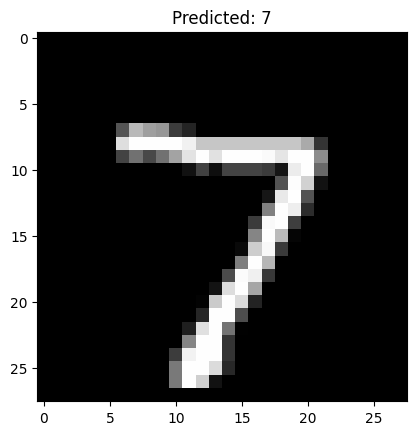

In [ ]:
#train the model
model.fit(x_train,y_train,epochs=5)
#evaluate on test data
test_loss,test_acc=model.evaluate(x_test,y_test)
print(f'Test accuracy:{test_acc:.4f}')
#display sample predictions
predictions=model.predict(x_test)
plt.imshow(x_test[0],cmap='grey')
plt.title(f'Predicted: {predictions[0].argmax()}')
plt.show()

In [ ]:
mnist

<module 'keras.datasets.mnist' from '/usr/local/lib/python3.12/dist-packages/keras/datasets/mnist/__init__.py'>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.9609 - loss: 0.1276 - val_accuracy: 0.9846 - val_loss: 0.0503
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9867 - loss: 0.0422 - val_accuracy: 0.9868 - val_loss: 0.0394
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9908 - loss: 0.0282 - val_accuracy: 0.9878 - val_loss: 0.0373
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9934 - loss: 0.0201 - val_accuracy: 0.9890 - val_loss: 0.0345
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9946 - loss: 0.0161 - val_accuracy: 0.9912 - val_loss: 0.0293
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9912 - loss: 0.0293
Test accuracy:0.9912
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


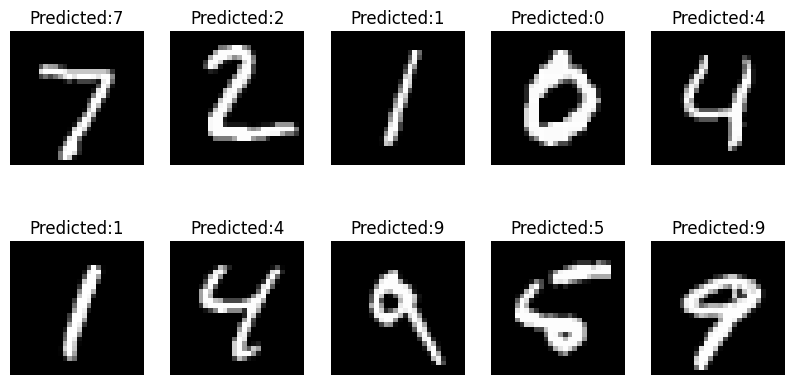

In [ ]:
mnist=keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()
#normalization
x_train,x_test=x_train/255.0,x_test/255.0
#reshape the data to include channel dimension(28,28,1)
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)
#Define CNN model
model=keras.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')

])

#compile model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
#trainmodel
model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))
#evaluate
test_loss,test_acc=model.evaluate(x_test,y_test)
print(f'Test accuracy:{test_acc:.4f}')
#predict on test images
predictions=model.predict(x_test)
#plot some predictions
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.title(f'Predicted:{predictions[i].argmax()}')
    plt.axis('off')
plt.show()